# RL Project 3: From Value Computation to Value & Policy Approximation

This notebook guides you through a full reinforcement learning pipeline on a simple Gridworld environment:

1. **Tabular value computation** (policy evaluation, value iteration)  
2. **Value approximation** with linear function approximation and semi-gradient TD  
3. **Neural value function approximation**  
4. **Policy approximation** using REINFORCE and Actor–Critic  

**Your tasks**:

- Read and run all cells.  
- Study and understand the provided implementations.  
- Where indicated with `TODO`, implement or modify code.  
- Use the notebook to generate figures for your written report.

Acknowledgement: I cowrote this using chatGTP 5.1 (specically, code writeup and formatting). However, the entire pipelining and assessment format is from the instructor and it aligns with expectation for the RL class.

If you go through each block, you will see how I have laid out, allowing to see all the stuff that we have learnt in class in one notebook.In specific places where you have to code, try go through the code and work on those areas, it should not be too streanous.

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# Optional: enable PyTorch for neural approximators
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not found. Neural network parts will not run unless you install `torch`.")

np.random.seed(42)


Number of states: 25 Number of actions: 4


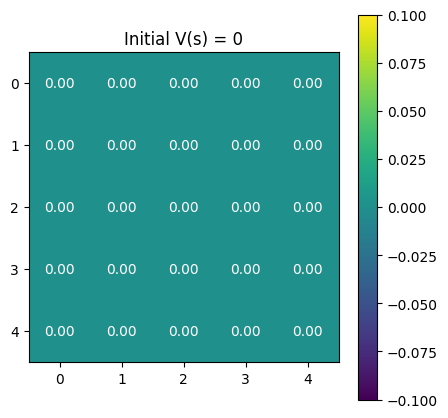

In [94]:
from dataclasses import dataclass

UP, RIGHT, DOWN, LEFT = 0, 1, 2, 3
ACTION_NAMES = {UP: "↑", RIGHT: "→", DOWN: "↓", LEFT: "←"}

@dataclass
class GridConfig:
    height: int = 5
    width: int = 5
    start_state: tuple = (0, 0)
    goal_state: tuple = (4, 4)
    step_cost: float = -0.01
    goal_reward: float = 1.0
    slip_prob: float = 0.1  # probability of taking a random action instead


class MiniGridworld:
    """
    A simple Gridworld environment.

    State: (row, col) integer coordinates.
    Actions: 0=UP, 1=RIGHT, 2=DOWN, 3=LEFT
    """
    def __init__(self, config: GridConfig = GridConfig()):
        self.config = config
        self.h = config.height
        self.w = config.width
        self.n_states = self.h * self.w
        self.n_actions = 4
        self.goal_state = config.goal_state
        self.start_state = config.start_state
        self.state = self.start_state

    def reset(self):
        self.state = self.start_state
        return self.state

    def in_bounds(self, r, c):
        return 0 <= r < self.h and 0 <= c < self.w

    def step(self, action):
        # Possibly slip to a random action
        if np.random.rand() < self.config.slip_prob:
            action = np.random.randint(self.n_actions)

        r, c = self.state

        if action == UP:
            nr, nc = r - 1, c
        elif action == RIGHT:
            nr, nc = r, c + 1
        elif action == DOWN:
            nr, nc = r + 1, c
        elif action == LEFT:
            nr, nc = r, c - 1
        else:
            raise ValueError("Unknown action.")

        if not self.in_bounds(nr, nc):
            nr, nc = r, c  # bump into wall, stay in place

        next_state = (nr, nc)

        # Rewards
        if next_state == self.goal_state:
            reward = self.config.goal_reward
            done = True
        else:
            reward = self.config.step_cost
            done = False

        self.state = next_state
        return next_state, reward, done, {}

    def state_to_index(self, s):
        r, c = s
        return r * self.w + c

    def index_to_state(self, idx):
        return (idx // self.w, idx % self.w)

    def all_states(self):
        for r in range(self.h):
            for c in range(self.w):
                yield (r, c)

    def is_terminal(self, s):
        return s == self.goal_state

    def render_values(self, V, title="State Values"):
        """
        V can be an array of shape (n_states,) or a dict mapping states to values.
        """
        grid = np.zeros((self.h, self.w))
        for r in range(self.h):
            for c in range(self.w):
                s = (r, c)
                if isinstance(V, dict):
                    v = V.get(s, 0.0)
                else:
                    v = V[self.state_to_index(s)]
                grid[r, c] = v
        plt.figure(figsize=(5, 5))
        plt.imshow(grid, cmap="viridis", origin="upper")
        for r in range(self.h):
            for c in range(self.w):
                plt.text(c, r, f"{grid[r,c]:.2f}", ha="center", va="center", color="white")
        plt.title(title)
        plt.colorbar()
        plt.show()

    def render_policy(self, policy, title="Policy"):
        """
        policy: array-like of shape (n_states,) giving greedy action, or dict s->a.
        """
        grid = np.full((self.h, self.w), " ")
        for r in range(self.h):
            for c in range(self.w):
                s = (r, c)
                if self.is_terminal(s):
                    grid[r, c] = "G"
                    continue
                if isinstance(policy, dict):
                    a = policy.get(s, 0)
                else:
                    a = policy[self.state_to_index(s)]
                grid[r, c] = ACTION_NAMES.get(int(a), "?")
        plt.figure(figsize=(5, 5))
        plt.imshow(np.zeros((self.h, self.w)), cmap="gray", origin="upper")
        for r in range(self.h):
            for c in range(self.w):
                plt.text(c, r, grid[r,c], ha="center", va="center", color="white", fontsize=16)
        plt.title(title)
        plt.axis("off")
        plt.show()


env = MiniGridworld()
print("Number of states:", env.n_states, "Number of actions:", env.n_actions)
env.render_values(np.zeros(env.n_states), title="Initial V(s) = 0")


---

## Part 1 — Tabular Value Computation

In this part you will:

1. Implement **policy evaluation** for a given policy π.  
2. Implement **value iteration** to compute the optimal value function and greedy policy.  

We represent:

- `V` as a NumPy array of shape `(n_states,)`  
- `policy` as a `(n_states, n_actions)` array giving π(a|s)


In [95]:
def build_uniform_random_policy(env: MiniGridworld):
    """
    Returns a policy array of shape (n_states, n_actions),
    where each action is equally likely.
    """
    policy = np.ones((env.n_states, env.n_actions)) / env.n_actions
    return policy

def one_step_lookahead(env: MiniGridworld, state, V, gamma=0.99):
    """
    Compute q(s,a) for all actions given V.
    Returns: q_values: np.array of shape (n_actions,)
    NOTE: this uses a single-sample transition for simplicity.
    """
    q = np.zeros(env.n_actions)
    for a in range(env.n_actions):
        # save and restore env.state to avoid side effects across actions
        old_state = env.state
        env.state = state
        next_state, reward, done, _ = env.step(a)
        env.state = old_state

        s_idx_next = env.state_to_index(next_state)
        if done:
            q[a] = reward
        else:
            q[a] = reward + gamma * V[s_idx_next]
    return q


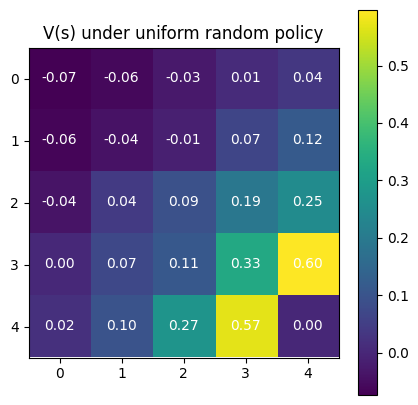

In [96]:
def policy_evaluation(env: MiniGridworld, policy, gamma=0.99, theta=1e-5, max_iterations=1000):
    """
    Iterative policy evaluation for a given policy π.
    Args:
        env: MiniGridworld
        policy: np.array of shape (n_states, n_actions)
        gamma: discount factor
        theta: small threshold for stopping
    Returns:
        V: np.array of shape (n_states,)
    """
    V = np.zeros(env.n_states)

    for it in range(max_iterations):
        delta = 0.0
        # TODO: implement iterative policy evaluation.
        # For each state s:
        #   - skip terminal states
        #   - compute q(s,a) for all actions using one_step_lookahead
        #   - V[s] = sum_a π(a|s) * q(s,a)
        #   - track max change |V_new - V_old| into delta
        # Stop when delta < theta.
        # ----------------- YOUR CODE HERE -----------------
        for state in env.all_states():
            if state == env.goal_state:
                continue

            i = env.state_to_index(state)

            q = one_step_lookahead(env, state, V, gamma)
            new_V = np.dot(policy[i], q)

            delta = max(delta, abs(new_V - V[i]))
            V[i] = new_V
        # -------------------------------------------------
        if delta < theta:
            print(f"Policy evaluation converged in {it+1} iterations.")
            break

    return V

# After you fill in policy_evaluation, run this cell:
policy = build_uniform_random_policy(env)
V_pi = policy_evaluation(env, policy, gamma=0.99)
env.render_values(V_pi, title="V(s) under uniform random policy")


Value iteration converged in 32 iterations.


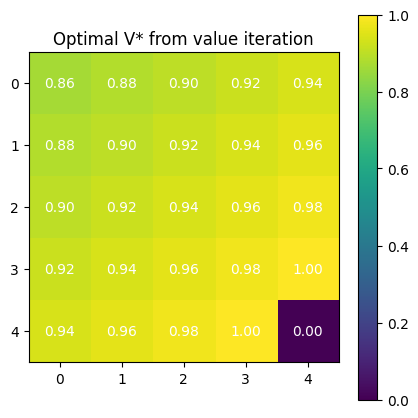

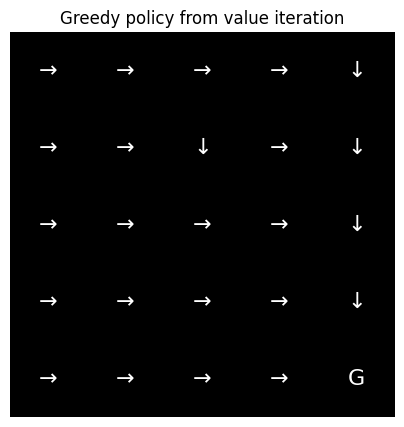

In [97]:
def value_iteration(env: MiniGridworld, gamma=0.99, theta=1e-5, max_iterations=1000):
    """
    Value Iteration to compute optimal value function and greedy policy.
    Returns:
        V: optimal values, shape (n_states,)
        policy: greedy policy (n_states, n_actions) one-hot
    """
    V = np.zeros(env.n_states)

    for it in range(max_iterations):
        delta = 0.0
        # TODO: implement value iteration
        # For each state s:
        #   - skip terminal states
        #   - compute q(s,a) using one_step_lookahead
        #   - V[s] = max_a q(s,a)
        #   - track max change into delta
        # ----------------- YOUR CODE HERE -----------------
        for state in env.all_states():
            if state == env.goal_state:
                continue

            i = env.state_to_index(state)

            q = one_step_lookahead(env, state, V, gamma)
            new_V = np.max(q)

            delta = max(delta, abs(new_V - V[i]))

            V[i] = new_V
        # -------------------------------------------------
        if delta < theta:
            print(f"Value iteration converged in {it+1} iterations.")
            break

    # TODO: construct greedy policy from V
    policy = np.zeros((env.n_states, env.n_actions))
    # For each non-terminal state, choose best action and set policy[s, best_a] = 1
    # ----------------- YOUR CODE HERE -----------------
    for state in env.all_states():
        if state == env.goal_state:
            continue

        i = env.state_to_index(state)

        q = one_step_lookahead(env, state, V, gamma)
        best_a = np.argmax(q)
        policy[i, best_a] = 1

    # -------------------------------------------------
    return V, policy

# After you fill in value_iteration, run this:
V_star, pi_star = value_iteration(env)
env.render_values(V_star, title="Optimal V* from value iteration")
greedy_actions = np.argmax(pi_star, axis=1)
env.render_policy(greedy_actions, title="Greedy policy from value iteration")


---

## Part 2 — Linear Value Function Approximation (Semi-Gradient TD)

Now we approximate the value function with a **linear function**:

$$
V_\theta(s) = \theta^{T} \phi(s)
$$

where φ(s) is a feature vector constructed from the state.

We will:

- Define a feature map φ(s).  
- Implement semi-gradient TD(0).  
- Implement semi-gradient TD(λ) with eligibility traces.  
- Compare with the tabular value function from Part 1.


In [98]:
def state_features(env: MiniGridworld, state):
    """
    Simple feature map φ(s).
    Returns a 1D np.array.
    """
    r, c = state
    h, w = env.h, env.w
    gr, gc = env.goal_state
    dist = abs(gr - r) + abs(gc - c)
    return np.array([
        r / (h - 1),        # normalized row
        c / (w - 1),        # normalized col
        1.0,                # bias term
        dist / (h + w - 2)  # normalized Manhattan distance to goal
    ], dtype=np.float32)

feat_dim = state_features(env, (0, 0)).shape[0]
print("Feature dimension:", feat_dim)


Feature dimension: 4


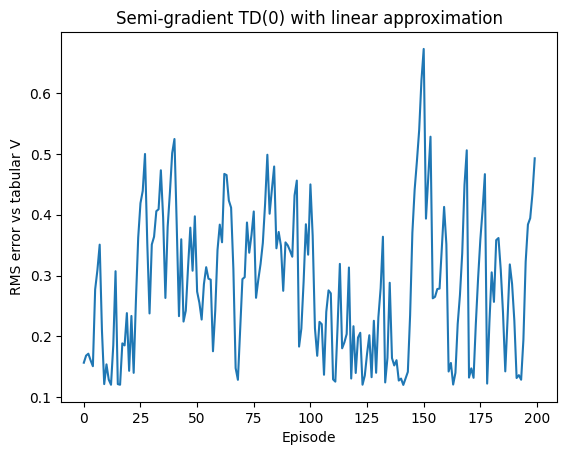

In [99]:
def semi_gradient_td0(
    env: MiniGridworld,
    policy,
    alpha=0.1,
    gamma=0.99,
    num_episodes=200
):
    """
    Semi-gradient TD(0) for policy evaluation with linear V_θ.
    """
    theta = np.zeros(feat_dim, dtype=np.float32)
    rms_history = []

    # use tabular policy evaluation as reference "true" V
    true_V = policy_evaluation(env, policy, gamma=gamma, max_iterations=2000)

    for ep in range(num_episodes):
        s = env.reset()
        done = False

        while not done:
            s_idx = env.state_to_index(s)
            a = np.random.choice(env.n_actions, p=policy[s_idx])

            phi_s = state_features(env, s)
            v_s = np.dot(theta, phi_s)

            next_state, reward, done, _ = env.step(a)

            # TODO: compute TD target and TD error
            # if done: td_target = reward
            # else: td_target = reward + gamma * V_theta(next_state)
            # then td_error = td_target - v_s
            # and update theta += alpha * td_error * phi_s
            # ----------------- YOUR CODE HERE -----------------
            if done:
                td_target = reward
            else:
                phi_next = state_features(env, next_state)
                v_next = np.dot(theta, phi_next)
                td_target = reward + (gamma * v_next)

            td_error = td_target - v_s
            theta += (alpha * td_error * phi_s)
            # -------------------------------------------------
            s = next_state

        # TODO: compute RMS error between approximate V and true_V
        # Hint: loop over all states, approximate V(s) using theta and state_features
        # ----------------- YOUR CODE HERE -----------------
        approx_V = np.zeros(true_V.shape)
        for state in env.all_states():
            i = env.state_to_index(state)
            phi_approx = state_features(env, state)
            approx_V[i] = np.dot(theta, phi_approx)

        rms = np.sqrt(np.mean((true_V - approx_V)**2))
        # -------------------------------------------------
        rms_history.append(rms)

    return theta, rms_history

# After you fill in TD(0), run:
theta_td0, rms_hist = semi_gradient_td0(env, policy, alpha=0.1, gamma=0.99, num_episodes=200)

plt.plot(rms_hist)
plt.xlabel("Episode")
plt.ylabel("RMS error vs tabular V")
plt.title("Semi-gradient TD(0) with linear approximation")
plt.show()


/var/folders/cv/26_7s9qd5233kq513mysjqv00000gn/T/ipykernel_11121/2674308096.py:47: RuntimeWarning: overflow encountered in multiply
  theta += (alpha * td_error * z)
/var/folders/cv/26_7s9qd5233kq513mysjqv00000gn/T/ipykernel_11121/2674308096.py:59: RuntimeWarning: overflow encountered in dot
  approx_V[i] = np.dot(theta, phi_approx)
/var/folders/cv/26_7s9qd5233kq513mysjqv00000gn/T/ipykernel_11121/2674308096.py:26: RuntimeWarning: overflow encountered in dot
  v_s = np.dot(theta, phi_s)
/var/folders/cv/26_7s9qd5233kq513mysjqv00000gn/T/ipykernel_11121/2674308096.py:41: RuntimeWarning: overflow encountered in dot
  v_next = np.dot(theta, phi_next)
/var/folders/cv/26_7s9qd5233kq513mysjqv00000gn/T/ipykernel_11121/2674308096.py:44: RuntimeWarning: invalid value encountered in scalar subtract
  td_error = td_target - v_s


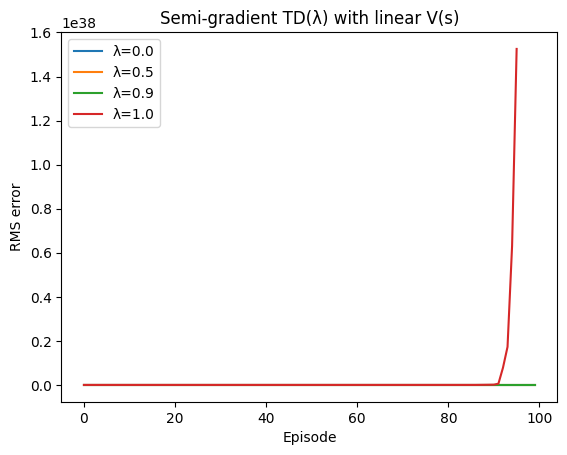

In [ ]:
def semi_gradient_td_lambda(
    env: MiniGridworld,
    policy,
    lambd=0.9,
    alpha=0.1,
    gamma=0.99,
    num_episodes=200
):
    """
    Semi-gradient TD(λ) with accumulating eligibility traces.
    """
    theta = np.zeros(feat_dim, dtype=np.float32)
    true_V = policy_evaluation(env, policy, gamma=gamma)
    rms_history = []

    for ep in range(num_episodes):
        s = env.reset()
        done = False
        z = np.zeros_like(theta)  # eligibility traces

        while not done:
            s_idx = env.state_to_index(s)
            a = np.random.choice(env.n_actions, p=policy[s_idx])

            phi_s = state_features(env, s)
            v_s = np.dot(theta, phi_s)

            next_state, reward, done, _ = env.step(a)

            # TODO:
            #   - compute td_target (similar to TD(0))
            #   - delta = td_target - v_s
            #   - update eligibility traces: z = gamma * lambda * z + phi_s
            #   - update theta += alpha * delta * z
            # ----------------- YOUR CODE HERE -----------------

            if done:
                td_target = reward
            else:
                phi_next = state_features(env, next_state)
                v_next = np.dot(theta, phi_next)
                td_target = reward + (gamma * v_next)

            td_error = td_target - v_s
            z = (gamma * lambd * z) + phi_s

            theta += (alpha * td_error * z)

            # -------------------------------------------------
            s = next_state

        # TODO: compute RMS error vs true_V (same as in TD(0))
        # ----------------- YOUR CODE HERE -----------------

        approx_V = np.zeros(true_V.shape)
        for state in env.all_states():
            i = env.state_to_index(state)
            phi_approx = state_features(env, state)
            approx_V[i] = np.dot(theta, phi_approx)

        rms = np.sqrt(np.mean((true_V - approx_V)**2))

        # -------------------------------------------------
        rms_history.append(rms)

    return theta, rms_history

# After you implement TD(λ), compare different λ values:
lambdas = [0.0, 0.5, 0.9, 1.0]
plt.figure()
for lam in lambdas:
    _, rms_hist_lam = semi_gradient_td_lambda(env, policy, lambd=lam, alpha=0.1, gamma=0.99, num_episodes=100)
    plt.plot(rms_hist_lam, label=f"λ={lam}")
plt.xlabel("Episode")
plt.ylabel("RMS error")
plt.title("Semi-gradient TD(λ) with linear V(s)")
plt.legend()
plt.show()


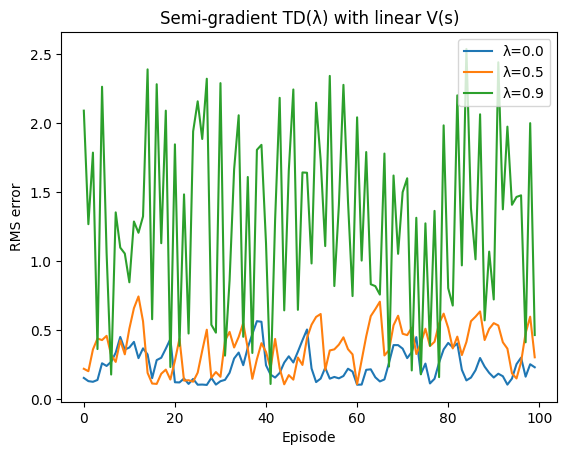

In [104]:
lambdas = [0.0, 0.5, 0.9]
plt.figure()
for lam in lambdas:
    _, rms_hist_lam = semi_gradient_td_lambda(env, policy, lambd=lam, alpha=0.1, gamma=0.99, num_episodes=100)
    plt.plot(rms_hist_lam, label=f"λ={lam}")
plt.xlabel("Episode")
plt.ylabel("RMS error")
plt.title("Semi-gradient TD(λ) with linear V(s)")
plt.legend()
plt.show()

---

## Part 3 — Neural Value Function Approximation

We now replace the linear function with a small neural network:

$$V_{\phi(s)} ≈ V^{*}(s)
$$

We will use PyTorch (if available) to implement a simple MLP and train it with TD(0).

This task requires that you go through the code/ reflect on it and then work on your final report

If PyTorch is not installed in your Colab session, run:

```bash
!pip install torch


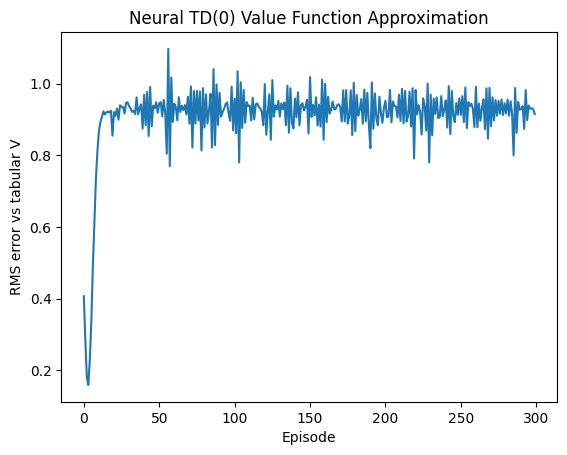

In [101]:

if not TORCH_AVAILABLE:
    print("PyTorch not installed, skipping neural value function section.")
else:
    class ValueNetwork(nn.Module):
        def __init__(self, input_dim, hidden_dim=32):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, 1)
            )

        def forward(self, x):
            return self.net(x)

    def td0_nn_value_function(
        env: MiniGridworld,
        policy,
        gamma=0.99,
        alpha=1e-3,
        num_episodes=500,
        hidden_dim=32
    ):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        net = ValueNetwork(feat_dim, hidden_dim=hidden_dim).to(device)
        optimizer = optim.Adam(net.parameters(), lr=alpha)

        true_V = policy_evaluation(env, policy, gamma=gamma)
        rms_history = []

        for ep in range(num_episodes):
            s = env.reset()
            done = False

            while not done:
                s_idx = env.state_to_index(s)
                a = np.random.choice(env.n_actions, p=policy[s_idx])

                phi_s = state_features(env, s)
                phi_s_t = torch.tensor(phi_s, dtype=torch.float32, device=device).unsqueeze(0)
                v_s = net(phi_s_t).squeeze(1)

                next_state, reward, done, _ = env.step(a)
                reward_t = torch.tensor([reward], dtype=torch.float32, device=device)

                # TODO: build TD target and loss
                # if done: target = reward_t
                # else: target = reward_t + gamma * V(next_state)
                # Use MSE loss between v_s and target.
                # ----------------- YOUR CODE HERE -----------------

                target = reward_t
                if not done:
                    phi_next = state_features(env, next_state)
                    phi_next_t = torch.tensor(phi_next, dtype=torch.float32, device=device).unsqueeze(0)
                    v_next = net(phi_next_t).squeeze(1)
                    target += (gamma * v_next)

                loss = nn.MSELoss()(v_s, target)

                # -------------------------------------------------
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                s = next_state

            # TODO: compute RMS vs true_V using the neural net
            # ----------------- YOUR CODE HERE -----------------

            approx_V = np.zeros(true_V.shape)
            for state in env.all_states():
                i = env.state_to_index(state)
                phi_approx = state_features(env, state)
                phi_approx_t = torch.tensor(phi_approx, dtype=torch.float32, device=device).unsqueeze(0)
                approx_V[i] = net(phi_approx_t).squeeze(1)
    
            rms = np.sqrt(np.mean((true_V - approx_V)**2))

            # -------------------------------------------------
            rms_history.append(rms)

        return net, rms_history

    net_value, rms_hist_nn = td0_nn_value_function(env, policy, gamma=0.99, alpha=1e-3, num_episodes=300)
    plt.plot(rms_hist_nn)
    plt.xlabel("Episode")
    plt.ylabel("RMS error vs tabular V")
    plt.title("Neural TD(0) Value Function Approximation")
    plt.show()


---

## Part 4 — Policy Approximation: REINFORCE and Actor–Critic

We now parameterize the policy directly using a softmax over features.

### REINFORCE

$
\nabla_\theta J(\theta) = \mathbb{E}_\pi [ G_t \nabla_\theta \log \pi_\theta(a_t \mid s_t) ]
$

### Actor–Critic

Use a value function as a baseline:

$
\delta_t = r_t + \gamma V_\phi(s_{t+1}) - V_\phi(s_t)
$

Actor update:

$
\theta \leftarrow \theta + \alpha_\pi \delta_t \nabla_\theta \log \pi_\theta(a_t \mid s_t)
$

Critic update:

$
\phi \leftarrow \phi + \alpha_v \delta_t \nabla_\phi V_\phi(s_t)
$


[REINFORCE] Episode 50, return = 0.910
[REINFORCE] Episode 100, return = 0.900
[REINFORCE] Episode 150, return = 0.900
[REINFORCE] Episode 200, return = 0.850
[REINFORCE] Episode 250, return = 0.820
[REINFORCE] Episode 300, return = 0.780
[REINFORCE] Episode 350, return = 0.880
[REINFORCE] Episode 400, return = 0.910


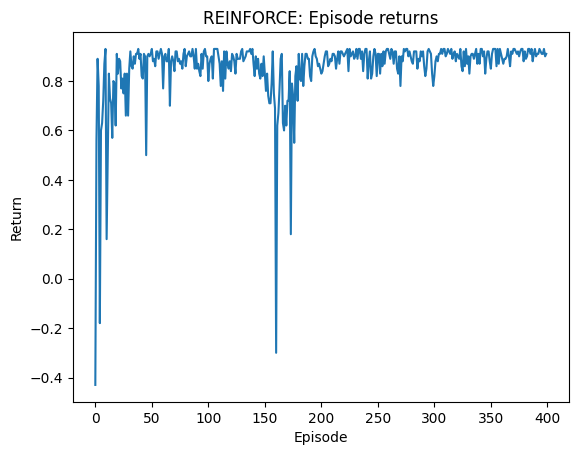

In [102]:
if not TORCH_AVAILABLE:
    print("PyTorch not installed, skipping policy approximation section.")
else:
    class PolicyNetwork(nn.Module):
        def __init__(self, input_dim, n_actions, hidden_dim=32):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, n_actions)
            )

        def forward(self, x):
            logits = self.net(x)
            return torch.distributions.Categorical(logits=logits)

    def run_episode_with_policy(env: MiniGridworld, policy_net, gamma=0.99, device="cpu"):
        """
        Generate one episode using given policy_net.
        Returns:
            states, actions, rewards, log_probs
        """
        states = []
        actions = []
        rewards = []
        log_probs = []

        s = env.reset()
        done = False

        while not done:
            phi = state_features(env, s)
            phi_t = torch.tensor(phi, dtype=torch.float32, device=device).unsqueeze(0)
            dist = policy_net(phi_t)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            next_state, reward, done, _ = env.step(action.item())

            states.append(s)
            actions.append(action)
            rewards.append(reward)
            log_probs.append(log_prob)

            s = next_state

        return states, actions, rewards, log_probs

    def reinforce(
        env: MiniGridworld,
        gamma=0.99,
        alpha=1e-2,
        num_episodes=500,
        hidden_dim=32
    ):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        policy_net = PolicyNetwork(feat_dim, env.n_actions, hidden_dim=hidden_dim).to(device)
        optimizer = optim.Adam(policy_net.parameters(), lr=alpha)

        returns_history = []

        for ep in range(num_episodes):
            states, actions, rewards, log_probs = run_episode_with_policy(env, policy_net, gamma=gamma, device=device)

            # TODO:
            #   - compute returns G_t for each time step (backwards)
            #   - normalize returns (optional but recommended)
            #   - compute REINFORCE loss: sum_t -log_pi(a_t|s_t) * G_t
            # ----------------- YOUR CODE HERE -----------------
            returns = [0.0 for state in states]
            for i in range(len(states)):
                idx = len(states) - i - 1
                if i == 0:
                    prev = 0.0
                else:
                    prev = returns[len(states) - i]

                returns[idx] = rewards[idx] + (gamma * prev)

            returns = np.array(returns)

            # normalize
            min_return = np.min(returns)
            max_return = np.max(returns)
            returns = (returns - min_return) / (max_return - min_return)
            returns_t = torch.tensor(returns, dtype=torch.float32, device=device)

            log_probs_t = torch.stack(log_probs).squeeze(1)

            loss = torch.sum((-log_probs_t) * returns_t)

            # -------------------------------------------------
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            episode_return = sum(rewards)
            returns_history.append(episode_return)

            if (ep + 1) % 50 == 0:
                print(f"[REINFORCE] Episode {ep+1}, return = {episode_return:.3f}")

        return policy_net, returns_history

    policy_net_rf, returns_rf = reinforce(env, gamma=0.99, alpha=1e-2, num_episodes=400)
    plt.plot(returns_rf)
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title("REINFORCE: Episode returns")
    plt.show()


[A2C] Episode 50, return = 0.790
[A2C] Episode 100, return = 0.910
[A2C] Episode 150, return = 0.920
[A2C] Episode 200, return = 0.890
[A2C] Episode 250, return = 0.920
[A2C] Episode 300, return = 0.890
[A2C] Episode 350, return = 0.920
[A2C] Episode 400, return = 0.930


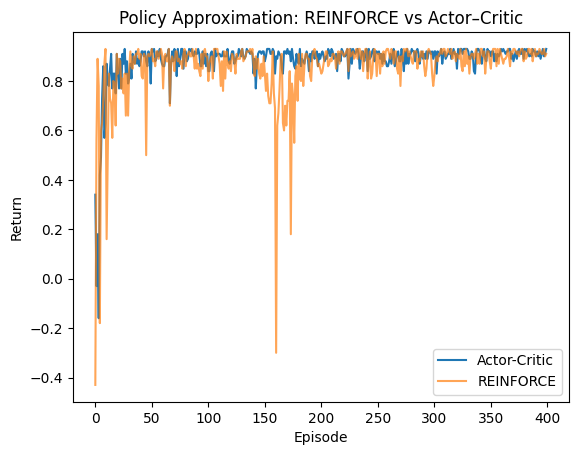

In [103]:
if TORCH_AVAILABLE:
    class ActorCriticNetworks(nn.Module):
        def __init__(self, input_dim, n_actions, hidden_dim=32):
            super().__init__()
            self.policy_net = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, n_actions)
            )
            self.value_net = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, 1)
            )

        def policy_dist(self, x):
            logits = self.policy_net(x)
            return torch.distributions.Categorical(logits=logits)

        def value(self, x):
            return self.value_net(x)

    def actor_critic(
        env: MiniGridworld,
        gamma=0.99,
        alpha_pi=1e-3,
        alpha_v=1e-3,
        num_episodes=500,
        hidden_dim=32
    ):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        ac = ActorCriticNetworks(feat_dim, env.n_actions, hidden_dim=hidden_dim).to(device)
        optimizer_pi = optim.Adam(ac.policy_net.parameters(), lr=alpha_pi)
        optimizer_v = optim.Adam(ac.value_net.parameters(), lr=alpha_v)

        returns_history = []

        for ep in range(num_episodes):
            s = env.reset()
            done = False
            episode_return = 0.0

            while not done:
                phi = state_features(env, s)
                phi_t = torch.tensor(phi, dtype=torch.float32, device=device).unsqueeze(0)

                dist = ac.policy_dist(phi_t)
                action = dist.sample()
                log_prob = dist.log_prob(action)

                value_s = ac.value(phi_t).squeeze(1)

                next_state, reward, done, _ = env.step(action.item())
                episode_return += reward

                # TODO:
                #   - compute td_target (reward + gamma * V(next_state) or just reward if done)
                #   - delta = td_target - value_s
                #   - critic loss: delta^2
                #   - actor loss: -log_prob * delta.detach()
                #   - update networks with two optimizers
                # ----------------- YOUR CODE HERE -----------------

                reward_t = torch.tensor([reward], dtype=torch.float32, device=device)
                target = reward_t
                if not done:
                    phi_next = state_features(env, next_state)
                    phi_next_t = torch.tensor(phi_next, dtype=torch.float32, device=device).unsqueeze(0)
                    v_next = ac.value(phi_next_t).squeeze(1)
                    target += (gamma * v_next)

                td_error = target - value_s

                optimizer_v.zero_grad()
                critic_loss = td_error ** 2
                critic_loss.backward()
                optimizer_v.step()

                optimizer_pi.zero_grad()
                actor_loss = (-log_prob) * td_error.detach()
                actor_loss.backward()
                optimizer_pi.step()

                # -------------------------------------------------
                s = next_state

            returns_history.append(episode_return)
            if (ep + 1) % 50 == 0:
                print(f"[A2C] Episode {ep+1}, return = {episode_return:.3f}")

        return ac, returns_history

    ac_model, returns_ac = actor_critic(env, gamma=0.99, alpha_pi=1e-3, alpha_v=1e-3, num_episodes=400)
    plt.plot(returns_ac, label="Actor-Critic")
    if 'returns_rf' in globals():
        plt.plot(returns_rf, label="REINFORCE", alpha=0.7)
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title("Policy Approximation: REINFORCE vs Actor–Critic")
    plt.legend()
    plt.show()


---

## Part 5 — Reflection & Comparative Analysis

For your **report** (upto 5 pages), use this notebook to generate plots and then (note you are not limited to the following, use the notebook as a learning and exploration tools):


1. Compare **tabular value iteration** with **linear TD** and **neural TD**:
   - Quality of the value estimates  
   - Sample efficiency  
   - Stability / divergence issues  

2. Compare **REINFORCE** with **Actor–Critic**:
   - Variance of returns  
   - Speed of learning  
   - Quality of final policies  

3. Include in your report:
   - Plots of training curves (returns vs episodes)  
   - Visualizations of value functions and policies  
   - A short discussion of when *approximation* helps and when it hurts.  

You may also experiment with:
- Changing grid size and goal location.  
- Increasing slip probability to make the environment more stochastic.  
- Modifying the feature map φ(s).

IMPORTANT: The report itself should be a pdf document NOT the notebook.
